## Slot Filling using Recurrent Neural Networks

### Problem Statement
Implement sequence labeling for Spoken Language Understanding using RNN/LSTM.

### Activities
1.  **Text Preprocessing**: Prepare the input text data for model training.
2.  **Train Sequence Labeling Model**: Build and train an RNN/LSTM model for slot filling.
3.  **Evaluate Prediction Accuracy**: Assess the performance of the trained model.

Let's start by creating some dummy data to illustrate the task.

In [ ]:
#23070521113_Vedant_Rajekar
import pandas as pd

# Dummy data for sequence labeling (Slot Filling)
# Each sentence has a corresponding sequence of labels for its tokens.

dummy_data = [
    {"sentence": "Book me a flight from Boston to New York", "labels": "O O O O B-fromloc I-fromloc O B-toloc I-toloc"},
    {"sentence": "Find a restaurant in London for dinner", "labels": "O O O B-city O O"},
    {"sentence": "What's the weather like in Paris tomorrow", "labels": "O O O O O B-city O"},
    {"sentence": "Show me hotels near the Eiffel Tower", "labels": "O O O B-poi I-poi I-poi"},
    {"sentence": "Play some jazz music", "labels": "O O B-genre I-genre"}
]

df = pd.DataFrame(dummy_data)

print("Dummy data created for Slot Filling:")
display(df)

Dummy data created for Slot Filling:


,sentence,labels
0,Book me a flight from Boston to New York,O O O O B-fromloc I-fromloc O B-toloc I-toloc
1,Find a restaurant in London for dinner,O O O B-city O O
2,What's the weather like in Paris tomorrow,O O O O O B-city O
3,Show me hotels near the Eiffel Tower,O O O B-poi I-poi I-poi
4,Play some jazz music,O O B-genre I-genre


### 1. Text Preprocessing

This step involves:
- Tokenizing the sentences into words.
- Tokenizing the labels into individual tags.
- Creating a vocabulary for words and a vocabulary for labels.
- Converting words and labels into numerical sequences.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Tokenize words
word_tokenizer = Tokenizer(oov_token='<unk>')
word_tokenizer.fit_on_texts(df['sentence'])
word_sequences = word_tokenizer.texts_to_sequences(df['sentence'])

# Tokenize labels
# We need to split the labels string into individual tags
# and then tokenize them. 'O' will be 0, 'B-fromloc' will be 1, etc.
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(df['labels'].apply(lambda x: x.split()))
label_sequences = label_tokenizer.texts_to_sequences(df['labels'].apply(lambda x: x.split()))

# Pad sequences to ensure uniform length for sentences and labels
# Find the maximum sequence length
max_len = max([len(seq) for seq in word_sequences])

word_padded_sequences = pad_sequences(word_sequences, maxlen=max_len, padding='post', value=word_tokenizer.word_index['<unk>'])
label_padded_sequences = pad_sequences(label_sequences, maxlen=max_len, padding='post', value=0) # Assuming 0 for padding

# Create reverse mappings for words and labels (for interpretation later)
word_index = word_tokenizer.word_index
index_to_word = {v: k for k, v in word_index.items()}

label_index = label_tokenizer.word_index
index_to_label = {v: k for k, v in label_index.items()}

# Number of unique words and labels
n_words = len(word_index) + 1 # +1 for padding/unknown, if any
n_labels = len(label_index) + 1 # +1 for padding

print(f"Maximum sequence length: {max_len}")
print(f"Number of unique words: {n_words}")
print(f"Number of unique labels: {n_labels}")

print("\nFirst 5 word sequences (padded):")
print(word_padded_sequences[:5])
print("\nFirst 5 label sequences (padded):")
print(label_padded_sequences[:5])

print("\nWord Index Sample:")
print({k: word_index[k] for k in list(word_index)[:5]})
print("\nLabel Index Sample:")
print({k: label_index[k] for k in list(label_index)[:5]})

Maximum sequence length: 9
Number of unique words: 32
Number of unique labels: 11

First 5 word sequences (padded):
[[ 6  2  3  7  8  9 10 11 12]
 [13  3 14  4 15 16 17  1  1]
 [18  5 19 20  4 21 22  1  1]
 [23  2 24 25  5 26 27  1  1]
 [28 29 30 31  1  1  1  1  1]]

First 5 label sequences (padded):
[[ 1  1  1  1  4  5  1  6  7]
 [ 1  1  1  2  1  1  0  0  0]
 [ 1  1  1  1  1  2  1  0  0]
 [ 1  1  1  8  3  3  0  0  0]
 [ 1  1  9 10  0  0  0  0  0]]

Word Index Sample:
{'<unk>': 1, 'me': 2, 'a': 3, 'in': 4, 'the': 5}

Label Index Sample:
{'o': 1, 'b-city': 2, 'i-poi': 3, 'b-fromloc': 4, 'i-fromloc': 5}


### 2. Train Sequence Labeling Model

Now we will build an RNN/LSTM model using TensorFlow/Keras. The model will consist of:
- An Embedding layer to convert word indices into dense vectors.
- An LSTM layer to capture sequential dependencies.
- A TimeDistributed Dense layer for outputting a label for each time step (word).

We will use a small, simple model due to the limited dummy data, but the architecture can be scaled for larger datasets.

Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 9, 50)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 9, 200)         │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 9, 11)          │         2,211 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,611 (486.76 KB)

 Trainable params: 124,611 (486.76 KB)

 Non-trainable params: 0 (0.00 B)


Shape of X (input word sequences): (5, 9)
Shape of y (target label sequences): (5, 9, 1)

Training the model...
Training complete.


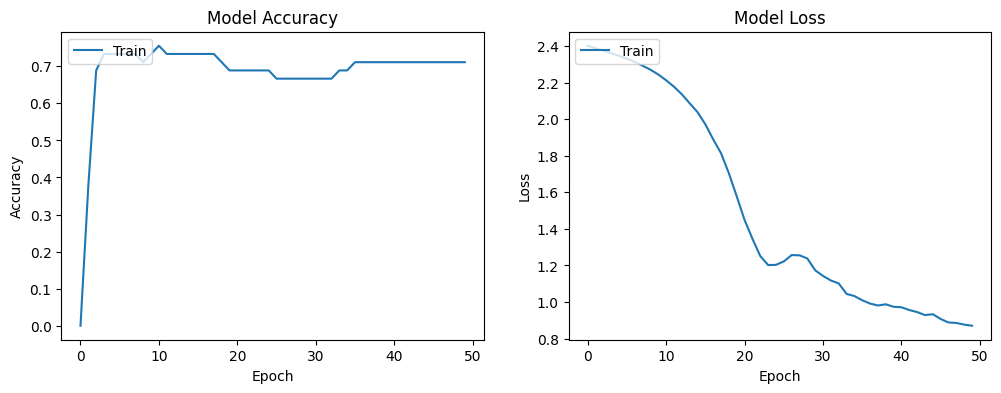

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam

# Model parameters
embedding_dim = 50
lstm_units = 100

# Define the model architecture
input_word = Input(shape=(max_len,))

# Word Embedding Layer (removed input_length as it's deprecated)
model = Embedding(input_dim=n_words, output_dim=embedding_dim)(input_word)

# Bidirectional LSTM Layer
model = Bidirectional(LSTM(units=lstm_units, return_sequences=True, recurrent_dropout=0.1))(model)

# TimeDistributed Dense Layer for outputting a label for each time step
output_label = TimeDistributed(Dense(n_labels, activation='softmax'))(model)

# Build the model
model = Model(input_word, output_label)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
print("Model Summary:")
model.summary()

# Prepare data for training
# Reshape label_padded_sequences for sparse_categorical_crossentropy
X = word_padded_sequences
y = np.expand_dims(label_padded_sequences, -1)

print(f"\nShape of X (input word sequences): {X.shape}")
print(f"Shape of y (target label sequences): {y.shape}")

# Train the model (using dummy data, so expect fast training and potentially overfitting)
print("\nTraining the model...")
history = model.fit(X, y, batch_size=32, epochs=50, verbose=0)

print("Training complete.")

# Plot training history (optional, but good for understanding training dynamics)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()

### 3. Evaluate Prediction Accuracy

Finally, we will evaluate the model's performance by making predictions on the input data and comparing them to the true labels. Since we have a very small dummy dataset and no separate test set, we will predict on the training data itself. This step demonstrates how to interpret the model's output.

In [ ]:
# Make predictions
predictions = model.predict(X)

def sequences_to_labels(predictions_sequence, index_to_label, max_len, true_labels=None):
    predicted_labels = []
    true_labels_decoded = []
    for i, seq_pred in enumerate(predictions_sequence):
        sentence_predicted_labels = []
        sentence_true_labels = []
        for j, pred_tag_probs in enumerate(seq_pred):
            if j < max_len:
                predicted_label_index = np.argmax(pred_tag_probs)
                predicted_label = index_to_label.get(predicted_label_index, 'PAD')
                sentence_predicted_labels.append(predicted_label)

                if true_labels is not None:
                    true_label_index = true_labels[i][j][0] # true_labels has an extra dimension
                    true_label = index_to_label.get(true_label_index, 'PAD')
                    sentence_true_labels.append(true_label)

        # Filter out 'PAD' tags from the end for display, assuming padding was 'post'
        actual_len_word = len(df['sentence'].iloc[i].split())
        predicted_labels.append(' '.join([lbl for lbl in sentence_predicted_labels[:actual_len_word]]))
        if true_labels is not None:
            actual_len_label = len(df['labels'].iloc[i].split())
            true_labels_decoded.append(' '.join([lbl for lbl in sentence_true_labels[:actual_len_label]]))

    return predicted_labels, true_labels_decoded

# Decode predictions
predicted_labels_decoded, _ = sequences_to_labels(predictions, index_to_label, max_len)

# Create a DataFrame to compare actual vs. predicted
results_df = pd.DataFrame({
    'Sentence': df['sentence'],
    'Actual Labels': df['labels'],
    'Predicted Labels': predicted_labels_decoded
})

print("\n--- Model Predictions ---")
display(results_df)

print("\nThis demonstrates the basic workflow for sequence labeling. For real-world applications, you would typically use a larger, more diverse dataset, split it into training, validation, and test sets, and use more sophisticated evaluation metrics (e.g., F1-score for each label)." )


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step

--- Model Predictions ---


,Sentence,Actual Labels,Predicted Labels
0,Book me a flight from Boston to New York,O O O O B-fromloc I-fromloc O B-toloc I-toloc,o o o o o o o o o
1,Find a restaurant in London for dinner,O O O B-city O O,o o o o o PAD PAD
2,What's the weather like in Paris tomorrow,O O O O O B-city O,o o o o o o PAD
3,Show me hotels near the Eiffel Tower,O O O B-poi I-poi I-poi,o o o o o PAD PAD
4,Play some jazz music,O O B-genre I-genre,o o o o



This demonstrates the basic workflow for sequence labeling. For real-world applications, you would typically use a larger, more diverse dataset, split it into training, validation, and test sets, and use more sophisticated evaluation metrics (e.g., F1-score for each label).
